# Computational Analysis of Single-Cell RNA Sequencing Data

The framework below performs cell analysis on expression matrices from experiments, which is quality controled first. Next, the data are visualized, and biologically meaningful patterns are identified through clustering and differential expression analysis. Finally, the results are verified to be biological. The scripts below illustrate how cells should be removed after QC review, then PCA, clustering, and UMAP should be rerun on the cleaned dataset.

### Workflow

1. Preprocessing and Alignment: Check sequencing quality metrics and generate a digital cell-by-gene count matrix.

2. Quality Control (QC) and Filtering: Remove empty droplets or low-quality barcodes that contain too few unique molecular identifiers (UMIs) or genes. Filter out dying or damaged cells with high mitochondrial gene percentages, as well as potential multi-cell doublets.

3. Normalization and Scaling: Normalize expression values and identify highly variable genes (HVGs) that drive biological heterogeneity across the cell population.

4. Dimensionality Reduction: Use Principal Component Analysis (PCA) to capture major sources of variation and reduce dataset complexity.  Project data into 2D space using t-SNE or UMAP to visually reveal distinct cellular neighborhoods.

5. Clustering and Annotation: Graph-Based Clustering: Group transcriptionally similar cells into clusters using algorithms like Louvain or Leiden. Cell-Type Annotation: Assign biological identities to clusters by identifying marker genes or using reference-based automated annotation tools.

6. Downstream Biological Analysis: Differential Expression: Find genes that vary between specific cell types, clusters, or experimental conditions (e.g., disease vs. control). Trajectory Inference: Order cells along a pseudotime developmental or activation pathway (using tools like Monocle or Slingshot). Cell-Cell Communication: Infer ligand-receptor interactions between different cell populations.


# Your Assignment:

After reviewing and running the scripts, submit a report answering the fllowing questions:

  * Do high-mitochondrial cells form a low-gene, low-count cluster?
  * Do high-count cells with low detected-gene content cluster together, and do their marker genes suggest a technical artifact or expected biology?
  * Do clusters separate primarily by cell cycle phase, and is proliferation expected for the sample?
  * Are flagged cells concentrated in one sample, one capture, or one cluster?
  * Are high mitochondrial or gene content expected for this dataset?
  * Play with the removal rule, e.g. removing low-gene cells, high-count low-gene cells, and predicted doublets, and describe your observations.
  * Determine optimal number of principle components.


In your report, include iteration on clustering: Try multiple resolutions and visualization methods and and check whether marker genes match expected cell types.

The current scripts performs single-cell analysis for human mature hepatocytes (hHEP): GSE81252. Rerun the scripts below for gene expression raw data available in NCBI GEO database under the following accession numbers: human embryonic stem cells (hESC): GSE75748, mouse embryonic stem cells (mESC): GSE98664, and mouse blood stem/progenitor cell (mHSC): GSE81682.


Before rerunning on the other three datasets, you would need to check if the dataset is already log-normalized. If raw data, then you would need `normalize_total` and `log1p` switched on in the script which are currently commented out.

Note that mouse genes use mt-, not MT-. (Lower case for animals).

Cell-cycle gene lists and marker sets need mouse versions.

The shape[0] > shape[1] transpose is heuristic and assumes that there are more genes that cells.  

Scrublet expects counts, so on 'log2' data it needs `2**x - 1` first (and doublets are rare in plate-based wells anyway).

In [ ]:
# Install Scanpy for single-cell analysis
!pip install -q scanpy anndata
# Install leidenalg and igraph packages required for sc.tl.leiden
!pip install -q leidenalg igraph

In [ ]:
import os
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

Mounted at /content/drive


In [ ]:
# Define the GEO supplementary file URL for GSE81252
geo_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE81nnn/GSE81252/suppl/GSE81252_data.cast.log2.liverbud.csv.gz"
file_path = "path/to/data.csv"

# Ensure the target directory exists
os.makedirs(os.path.dirname(file_path), exist_ok=True)

# Download the file if it hasn't been downloaded already
if not os.path.exists(file_path):
    print("Downloading GSE81252 dataset...")
    !wget -O "$file_path" "$geo_url"
else:

    print("Dataset already downloaded.")

Dataset already downloaded.


The following script loads a compressed single-cell expression dataset (usually a CSV file) and converts it into an AnnData object, which is the standard format used by the Scanpy library for single-cell analysis.


In [ ]:
try:
    print("Parsing expression matrix...")
    # Reads the compressed file (.csv.gz) from file_path using Pandas.
    # index_col=0 sets the first column of the file (usually gene names
    # or cell IDs) as the row labels (index).
    df = pd.read_csv(file_path, index_col=0, compression='gzip')

    # Identify and separate non-numeric columns
    # Single-cell expression values are numbers (expression counts/levels),
    # but files often contain additional columns for cell metadata.
    numeric_cols = df.select_dtypes(include=['number']).columns
    non_numeric_cols = df.select_dtypes(exclude=['number']).columns

    if len(non_numeric_cols) > 0:
        print(f"Found non-numeric columns to extract: {list(non_numeric_cols)}")
        # We can store these as cell observations later if needed
        metadata_df = df[non_numeric_cols]
        df_numeric = df[numeric_cols]
    else:
        df_numeric = df

    # Transpose matrix to format (cells x genes) if needed
    # Scanpy standardizes data structures such that rows represent
    # cells and columns represent genes.
    if df_numeric.shape[0] > df_numeric.shape[1]:
        print(f"Transposing matrix from shape {df_numeric.shape}...")
        df_numeric = df_numeric.T

    # Convert to Scanpy AnnData object (with float32 conversion built-in)
    adata = sc.AnnData(df_numeric.astype('float32'))
    # same as: adata = sc.read_csv('path/to/data.csv')

    # Re-attach extracted metadata to adata.obs if applicable.
    # If non-numeric columns were found earlier (in this dataset,
    # 'experiment' and 'assignment_LB'), they are aligned with the
    # correct cell index and stored inside adata.obs (which holds cell-level metadata).
    if len(non_numeric_cols) > 0:
        # Ensure index alignment matches cells
        adata.obs = metadata_df.loc[adata.obs_names]

    # del df, df_numeric  # Free up RAM
    print(f"Success! AnnData created with {adata.n_obs} cells and {adata.n_vars} genes.")

except Exception as e:
    print(f"Error loading file: {e}")

Parsing expression matrix...
Found non-numeric columns to extract: ['experiment', 'assignment_LB']
Success! AnnData created with 465 cells and 19020 genes.


Quick reference guide and interactive inspection of the structure of an AnnData (Annotated Data) object, which is the standard format used by Python's Scanpy library to represent single-cell RNA-seq datasets.

In [ ]:
adata.X          # Expression matrix (cells × genes)
adata.obs        # Cell metadata (DataFrame)
adata.var        # Gene metadata (DataFrame)
adata.uns        # Unstructured annotations (dict)
adata.obsm       # Multi-dimensional cell data (PCA, UMAP)
adata.raw        # Raw data backup

# Access cell and gene names
adata.obs_names  # Cell barcodes
adata.var_names  # Gene names

Index(['ESRG', 'OR4F5', 'OR4F29', 'OR4F16', 'SAMD11', 'NOC2L', 'KLHL17',
       'PLEKHN1', 'PERM1', 'HES4',
       ...
       'PRY', 'BPY2', 'DAZ1', 'DAZ2', 'CDY1B', 'BPY2B', 'DAZ3', 'DAZ4',
       'BPY2C', 'CDY1'],
      dtype='str', length=19020)

In [ ]:
print(df)
print(df_numeric)

         experiment assignment_LB  ESRG  OR4F5  OR4F29  OR4F16    SAMD11  \
cell_id                                                                    
A1_he2          he2            HE     0      0     0.0       0  3.516179   
A1_huvec      huvec            EC     0      0     0.0       0  0.000000   
A1_lb1          lb1         MC-LB     0      0     0.0       0  0.000000   
A1_msc2        msc2            MC     0      0     0.0       0  0.000000   
A10_he1         he1            HE     0      0     0.0       0  2.439522   
...             ...           ...   ...    ...     ...     ...       ...   
H8_msc2        msc2            MC     0      0     0.0       0  0.000000   
H9_huvec      huvec            EC     0      0     0.0       0  0.000000   
H9_lb3          lb3         HE-LB     0      0     0.0       0  0.000000   
H9_lb4          lb4         HE-LB     0      0     0.0       0  3.654080   
H9_msc2        msc2            MC     0      0     0.0       0  0.000000   

           

This code block performs basic Quality Control (QC) and distribution analysis on the single-cell expression matrix. It checks if the dataset has already been log-normalized and creates two distribution plots to help you understand the spread of average gene expression across all cells.

(465, 19020)
Missing values: 0
If > 0, then log transformation needed: 0.0
If > 100, then log transformation needed: 16.2409496771373
Average expression per cell: 1.2703237797381992


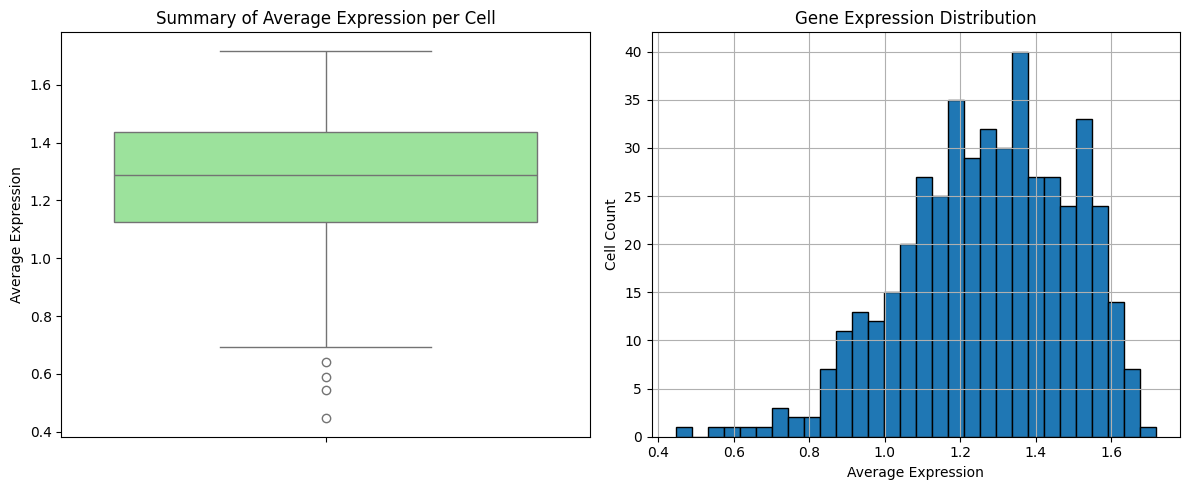

In [ ]:
# NOTE: GSE81252 cell-by-gene dataset is already log-normalized

expression_df = df_numeric
print(expression_df.shape)  # cells(samples) x genes
# Check for missing values
print(f"Missing values: {expression_df.isnull().sum().sum()}")
print(f"If > 0, then log transformation needed: {expression_df.min().min()}")
print(f"If > 100, then log transformation needed: {expression_df.max().max()}")
print(f"Average expression per cell: {expression_df.mean(axis=1).mean()}")


# Log transformation (if needed)
if expression_df.min().min() > 0:  # Check if already log-transformed
    if expression_df.max().max() > 100:
        expression_df = np.log2(expression_df + 1)
        print("Applied log2 transformation")

# Distribution plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
#expression_df.plot.box(ax=plt.gca())
#plt.title("Expression Distribution per Sample")
#plt.xticks(rotation=90)
sns.boxplot(y=expression_df.mean(axis=1), color='lightgreen') # Summary box plot of cell means
plt.title("Summary of Average Expression per Cell")
plt.ylabel("Average Expression")

plt.subplot(1, 2, 2)
expression_df.mean(axis=1).hist(bins=30, edgecolor='black')
plt.title("Gene Expression Distribution")
plt.xlabel("Average Expression")
plt.ylabel("Cell Count")

plt.tight_layout()
plt.savefig("geo_qc.png", dpi=300, bbox_inches='tight')

In [ ]:
import numpy as np

def filter_highly_variable_genes(matrix_df, top_k=500):
    """Filters an n x m matrix down to the top_k most variable genes.

    Parameters:
    matrix_df (pd.DataFrame): Rows = Genes (n), Columns = Cells (m)
    top_k (int): Number of differential genes to keep (e.g., 500 or 1000)
    """
    print(f"Original matrix shape (Rows = Genes (n), Columns = Cells (m)): {matrix_df.shape}")

    # Calculate the variance for each gene (row-wise) across all cells
    # Note: If cells are rows, change axis to 0
    gene_variances = matrix_df.var(axis=1)

    # Add the variance calculation back to the dataframe for sorting
    processed_df = matrix_df.copy()
    processed_df["variance"] = gene_variances

    # Sort by variance in descending order
    processed_df = processed_df.sort_values(by="variance", ascending=False)

    # Extract the top K genes and drop the helper variance column
    filtered_matrix = processed_df.head(top_k).drop(columns=["variance"])

    print(f"Filtered matrix shape (Rows = Genes (n), Columns = Cells (m)): {filtered_matrix.shape}")
    return filtered_matrix.T


# --- Example Usage Pipeline ---
# Simulating an expression matrix (10,000 genes x 800 cells)
#np.random.seed(42)
#mock_genes = [f"Gene_{i}" for i in range(10000)]
#mock_cells = [f"Cell_{j}" for j in range(800)]
# Generate log-normal distributed mock single-cell counts
#mock_data = np.random.lognormal(mean=1.5, sigma=2.0, size=(10000, 800))

#expression_df = pd.DataFrame(mock_data, index=mock_genes, columns=mock_cells)

# NOTE: expression_df from dataset is in: Rows = Cells (n), Columns = Genes (m) format
# filter_highly_variable_genes() takes Rows = Genes (n), Columns = Cells (m)

# Apply filtering for the top 500 most differential genes
filtered_500_df = filter_highly_variable_genes(expression_df.T, top_k=500)

# Apply filtering for the top 1000 most differential genes
filtered_1000_df = filter_highly_variable_genes(expression_df.T, top_k=1000)

# Save your processed sub-matrix to prepare it for GraphSAGE input
file_path="/content/drive/MyDrive/Teaching/Math391/2026f/project/GRN/ige_input_matrix_500.csv"
filtered_500_df.to_csv(file_path)
filtered_500_df

Original matrix shape (Rows = Genes (n), Columns = Cells (m)): (19020, 465)
Filtered matrix shape (Rows = Genes (n), Columns = Cells (m)): (500, 465)
Original matrix shape (Rows = Genes (n), Columns = Cells (m)): (19020, 465)
Filtered matrix shape (Rows = Genes (n), Columns = Cells (m)): (1000, 465)


,APOA2,APOA1,DCN,TGFBI,CKB,ANXA1,MT2A,KRT19,SERPINE1,EFEMP1,...,CNOT10,IFT57,STAM,SLC7A7,AP1G2,TNFRSF12A,C1orf198,TNFAIP8,ICA1,FZD5
cell_id,,,,,,,,,,,,,,,,,,,,,
A1_he2,12.409219,12.903801,0.000000,0.000000,10.395695,0.000000,1.898502,10.496654,0.475541,0.000000,...,7.339298,4.021373,5.452101,5.999200,5.717860,5.808588,3.790720,3.487898,0.000000,3.856099
A1_huvec,0.000000,0.000000,0.000000,4.696100,0.000000,10.231329,12.377558,0.000000,10.541000,11.192533,...,0.000000,3.668187,3.555264,0.000000,3.921474,6.051274,5.224905,0.000000,6.741696,0.000000
A1_lb1,4.312905,0.638704,11.073137,9.042852,7.611799,8.510653,12.575421,1.434385,6.775828,0.000000,...,0.000000,0.000000,3.150945,0.000000,5.160323,4.822037,6.444008,4.505084,0.000000,0.000000
A1_msc2,0.000000,0.000000,7.954854,8.715928,1.009999,7.213114,9.644543,0.000000,5.797158,6.411391,...,0.000000,0.000000,0.000000,0.000000,0.000000,7.471448,5.987698,4.648333,0.000000,0.000000
A10_he1,12.858548,12.806650,0.000000,0.000000,9.722480,0.000000,3.280944,11.209429,0.000000,0.000000,...,2.566927,5.217847,3.924642,5.488493,6.455372,2.987443,3.224639,0.000000,0.000000,5.492379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H8_msc2,0.000000,0.000000,8.264818,10.122802,6.599252,8.931659,8.763949,0.000000,3.656405,7.807786,...,5.553895,4.030389,5.302476,0.000000,0.000000,5.392657,7.477167,0.857384,0.000000,1.811401
H9_huvec,0.000000,0.000000,0.000000,0.000000,0.000000,9.416804,10.812145,2.860444,9.309272,11.279999,...,4.689786,5.630746,1.644387,0.553734,0.000000,5.603110,3.487242,0.000000,2.436495,0.000000
H9_lb3,12.896896,5.105766,5.617898,0.000000,9.352723,7.462715,9.016507,3.938229,3.987839,0.000000,...,0.000000,4.569169,0.000000,7.488531,4.355644,0.000000,0.000000,0.000000,0.000000,5.090146


This code block evaluates similarity and relationships among cell samples using the top 50 highly variable genes (HVGs). It performs two main tasks:

  1- Sample Correlation Heatmap: Computes and visualizes pairwise correlation coefficients between cell profiles. `sns.heatmap`: Visualizes the pairwise correlation matrix.
`cmap='coolwarm'`: High positive correlations appear warm (red), and low/negative correlations appear cool (blue).
`center=0`: Anchors the color scale midpoint at zero.

  2- Hierarchical Clustering: Groups transcriptionally similar cells together using a dendrogram to reveal structural clusters in the sample population. `hierarchy.linkage`: Performs hierarchical agglomerative clustering on the distance matrix using the average linkage method (UPGMA), which links clusters based on the average distance between their members.
`hierarchy.dendrogram`: Renders the clustering tree. The branch splits (dendrogram forks) represent how closely related cell clusters are. Short branches indicate highly similar transcriptional profiles.

Original matrix shape (Rows = Genes (n), Columns = Cells (m)): (19020, 465)
Filtered matrix shape (Rows = Genes (n), Columns = Cells (m)): (50, 465)


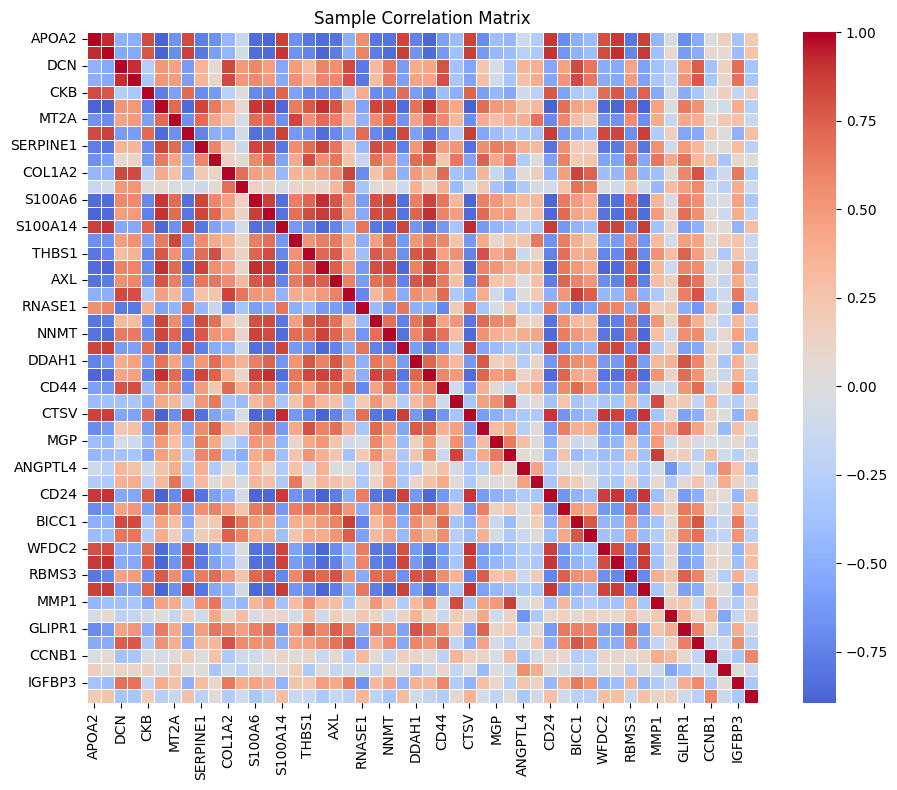

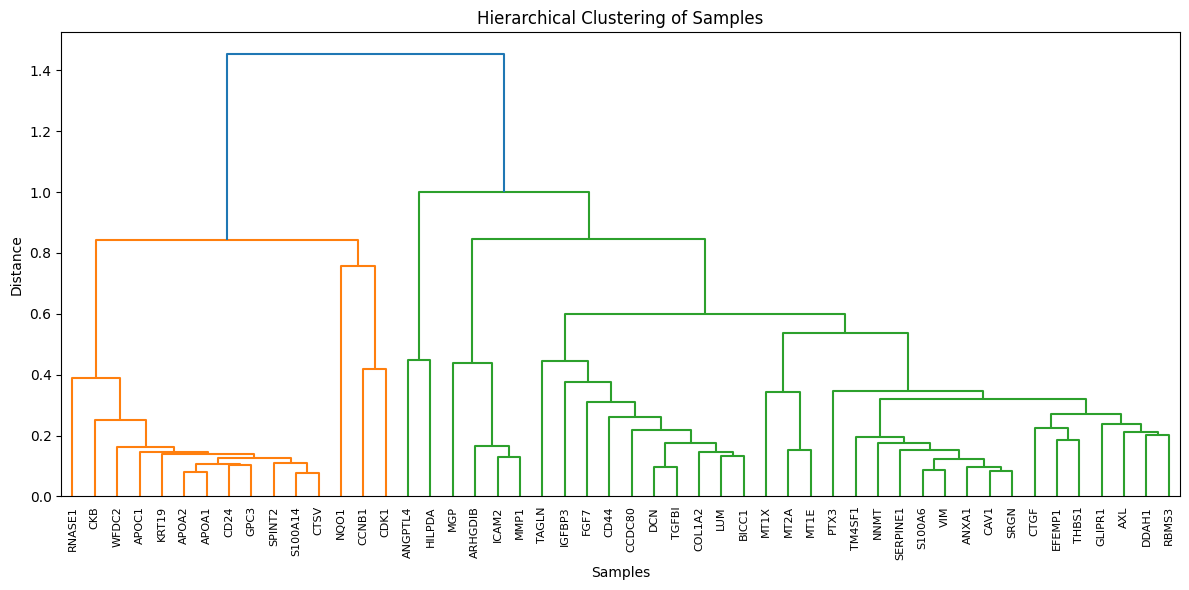

In [ ]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist

# Sample correlation heatmap using 50 highly variable genes subset
filtered_50_df = filter_highly_variable_genes(expression_df.T, top_k=50)
sample_corr = filtered_50_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(sample_corr, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title("Sample Correlation Matrix")
plt.tight_layout()
plt.savefig("sample_correlation.png", dpi=300, bbox_inches='tight')

# Hierarchical clustering using the highly variable genes
# Since some cells might still have zero variance or NaNs under correlation, we check and clean
distances = pdist(filtered_50_df.T, metric='correlation')

# Replace any NaN distances (from zero variance cells) with maximum distance (1.0 or 2.0)
if np.isnan(distances).any():
    print("Warning: NaN distances detected and filled.")
    distances = np.nan_to_num(distances, nan=1.0)

linkage = hierarchy.linkage(distances, method='average')

plt.figure(figsize=(12, 6))
hierarchy.dendrogram(linkage, labels=filtered_50_df.columns)
plt.title("Hierarchical Clustering of Samples")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("sample_clustering.png", dpi=300, bbox_inches='tight')
plt.show()

The following script calculates standard QC (quality control) statistics for every single cell. This includes the total number of molecules detected (RNA counts), the number of unique genes expressed, and the percentage of those counts that belong to the flagged mitochondrial genes.

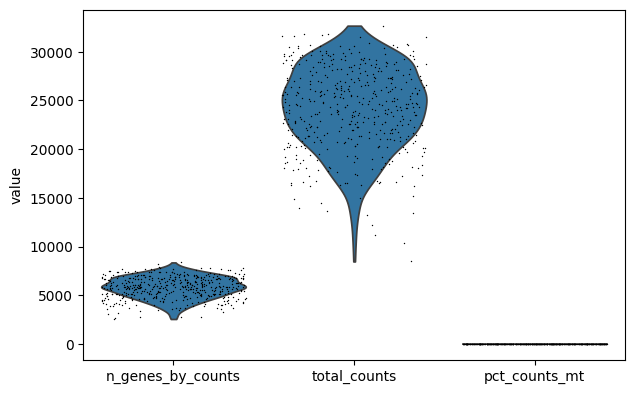

In [ ]:
# Identify mitochondrial genes
# It identifies low-quality cells and poorly expressed genes so
# they can be removed before downstream analysis.
# High mitochondrial (MT-) content is a classic signature of broken, dying, or stressed cells that have leaked their cytoplasmic RNA.
adata.var['mt'] = adata.var_names.str.startswith('MT-')

# Calculate QC metrics (percentage of those counts that belong to the flagged mitochondrial genes)
sc.pp.calculate_qc_metrics(adata,
                           qc_vars=['mt'],
                           percent_top=None,
                           log1p=False,
                           inplace=True)

# Visualize QC metrics (Generates violin plots across three key metrics to help you see the distribution of data and choose your filtering thresholds visually)
# total_counts: Total number of reads in a cell
# n_genes_by_counts: Total number of non-zero genes per individual cell
# pct_counts_mt: Percentage of counts in MT- genes - percentage of total sequencing reads (counts) in a cell that map to a specific group of genes

sc.pl.violin(adata,
            ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4,
             multi_panel=False)

# Filter cells and genes
sc.pp.filter_cells(adata, min_genes=200) # Removes empty droplets or dying cells that express fewer than 200 distinct genes.
sc.pp.filter_genes(adata, min_cells=3) # Removes rare genes that appear in fewer than 3 cells, as they are not statistically useful for cluster analysis.
# keep genes detected in at least 0.1% of cells, with a minimum of 3 cells.

# Filter out the lower tail (adjust 15000 based on where your violin tail thins out)
#adata = adata[adata.obs['total_counts'] > 15000, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]  # Remove high MT% cells

In [ ]:
adata.obs[
    [
        "total_counts", # Total number of reads in a cell
        "n_genes_by_counts", # Total number of non-zero genes per individual cell
        "pct_counts_mt", # Percentage of counts in genes - percentage of total sequencing reads (counts) in a cell that map to a specific group of genes
    ]
].describe()

,total_counts,n_genes_by_counts,pct_counts_mt
count,465.000000,465.000000,465.0
mean,24161.556641,5829.752688,0.0
std,4199.072266,1084.827833,0.0
min,8490.100586,2588.000000,0.0
25%,21383.199219,5122.000000,0.0
50%,24529.427734,5897.000000,0.0
75%,27341.597656,6694.000000,0.0
max,32676.195312,8388.000000,0.0


The vast majority of the cells in this dataset share a nearly identical total sum of log-expression values (~25,000). You don't have to worry about severe technical batch effects where some cells have massive amounts of data and others have almost none.

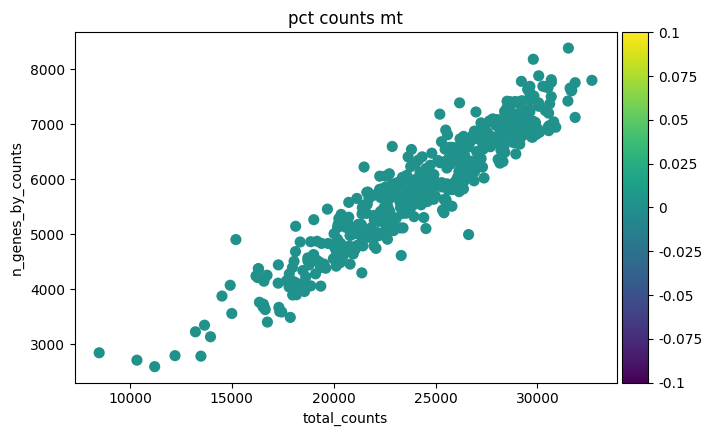

In [ ]:
sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mt",
)

Single-cell datasets contain thousands of genes, but many are uninformative for cell-state structure. Highly variable gene (HVG) selection focuses the analysis on genes whose variation is higher than expected for their mean expression. Use HVGs as a feature mask for PCA, neighbors, clustering, and UMAP. Keep all genes in the main AnnData object for marker inspection, annotation, and saving.


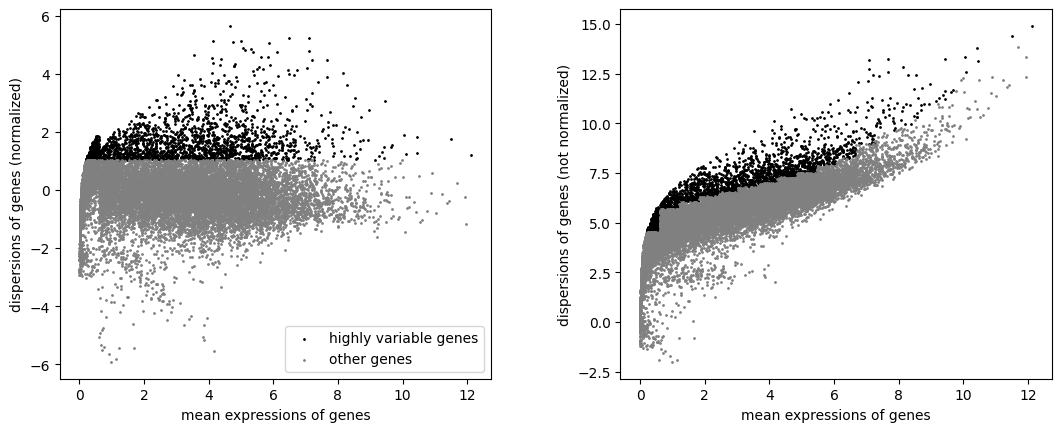

/usr/lib/python3.13/functools.py:934: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)


highly_variable
True    2000
Name: count, dtype: int64


In [ ]:
# Normalize to 10,000 counts per cell
#sc.pp.normalize_total(adata, target_sum=1e4)

# Log-transform
#sc.pp.log1p(adata)

# Save raw counts for later
adata.raw = adata

# Identify highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pl.highly_variable_genes(adata)

# Subset to highly variable genes
# Highly variable genes define which signals enter dimensionality
# reduction without dropping other genes from the cleaned object.
adata = adata[:, adata.var.highly_variable]

# Regress out unwanted variation
#sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])

# Scale data to unit variance and zero mean.
sc.pp.scale(adata, max_value=10)

print(adata.var["highly_variable"].value_counts())

PCA identifies linear combinations of genes that explain major axes of variation. Here, PCA uses the highly variable genes without subsetting the AnnData object. These axes can reflect biology, but also batch, count depth, mitochondrial content, or other technical structure.

Clustering partitions the neighbor graph into groups of transcriptionally similar cells. Leiden clustering identifies communities in the neighbor graph. The resolution parameter controls granularity. There is no universally correct resolution.

Building the neighbor graph: The neighbor graph defines which cells are considered locally similar. Clustering and UMAP are based on a graph of nearest neighbors. This graph is usually built from PCA coordinates, not directly from all genes. The n_pcs choice controls which PCA dimensions are passed into this graph, so it directly affects clustering and UMAP.


UMAP visualizes the neighbor graph and helps inspect QC flags. UMAP projects the neighbor graph into two dimensions (scatter plot). It is useful for inspection and communication, but distances and separations in UMAP should not be overinterpreted. In the first pass, include QC flags, doublet scores, core QC metrics, and cell cycle scores on the UMAP. A cluster enriched for QC flags or cell cycle phase is a reason to inspect the cells, not automatic proof that the cluster should be removed.

Every cell in the human liver bud dataset (GSE81252) measures the expression of roughly 20,000 different genes (dataset has 20,000 dimensions). UMAP solves this problem by compressing those 20,000 dimensions into just two axes (UMAP1 and UMAP2).


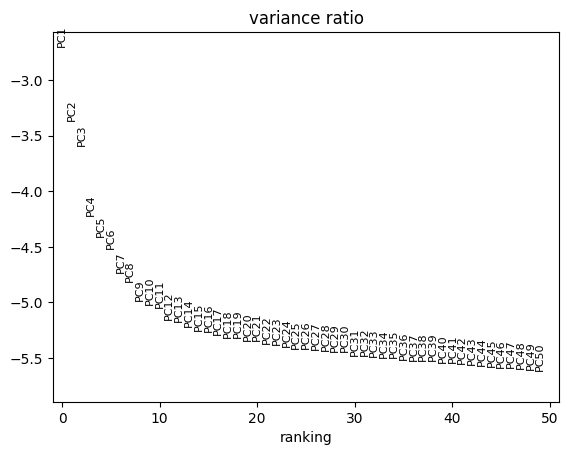

/tmp/ipykernel_1034/663526646.py:29: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata)


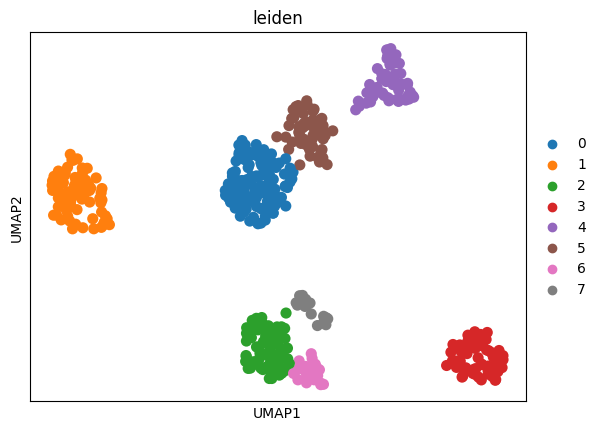

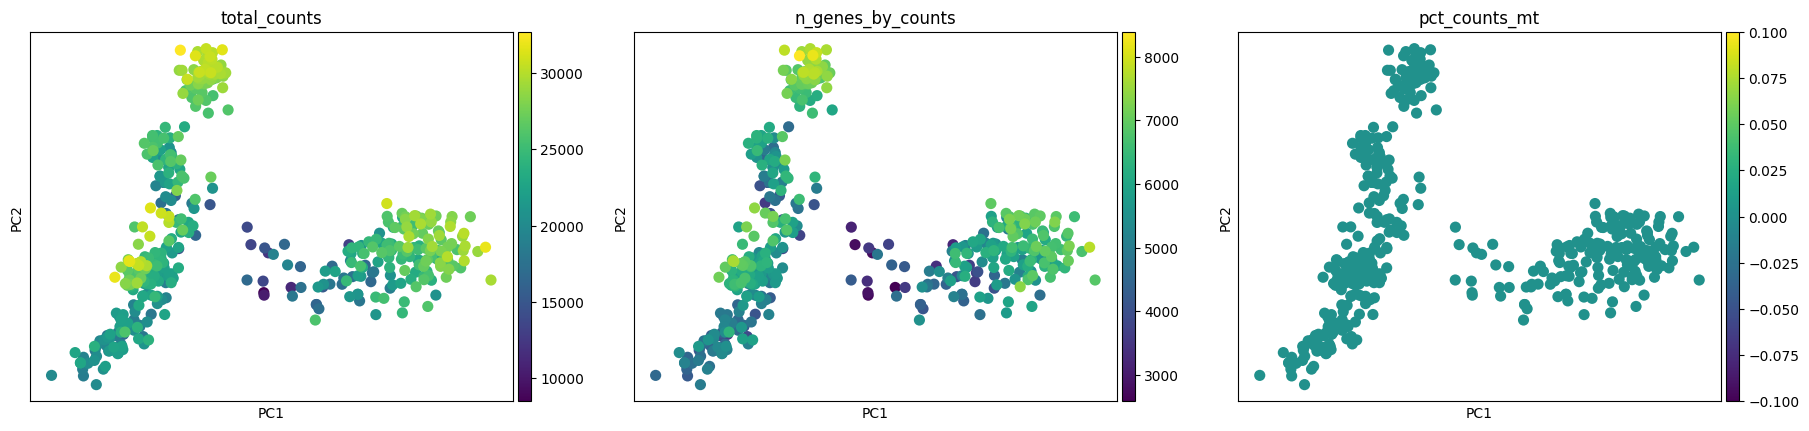

In [ ]:
# PCA
# The PCA variance-ratio plot is the elbow plot for this workflow.
# It shows how much variance is explained by each successive
# principal component. A useful starting point is the region where
# the curve begins to flatten: PCs before that point usually capture
# stronger structure, while PCs far into the flat tail are more
# likely to add noise. The elbow is a guideline, not a rule. Too few
# PCs can merge real cell states, rare populations, or continuous
# gradients. Too many PCs can carry technical variation,
# low-quality-cell structure, or noise into the neighbor graph.
# Small, fairly homogeneous datasets may work well with 15-30 PCs.
# Larger datasets, complex tissues, tumor samples, developmental
# trajectories, immune atlases, or datasets with rare cell
# populations may need 40, 50, or more PCs.

# After choosing n_pcs, inspect whether clusters have coherent
# marker genes and whether UMAP structure is dominated by QC
# metrics such as count depth, mitochondrial fraction,
# doublet score, or cell cycle. If the representation is unstable
# or biologically implausible, rerun the neighbor graph and UMAP
# with a different PC count.
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)  # Check elbow plot

# Compute neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

# Run clustering algorithm
sc.tl.leiden(adata)

# UMAP for visualization
sc.tl.umap(adata)
sc.pl.umap(adata, color='leiden')

# Alternative: t-SNE
# sc.tl.tsne(adata)

# This checks whether major PCs are dominated by count depth or mitochondrial fraction.
sc.pl.pca(
    adata,
    color=[
        "total_counts",
        "n_genes_by_counts",
        "pct_counts_mt",
    ],
)

When you look at UMAP graph, each cluster consists of dots, where each dot is a single cell. Cells that are close together share very similar gene expression profiles (meaning they are likely the same cell type, like Hepatocytes). Cells that are far apart are biologically very different. The actual values on the UMAP1 and UMAP2 axes do not mean anything specific (and have no units). Only the relative positioning and clustering of the dots matter.

/tmp/ipykernel_1034/600126637.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)


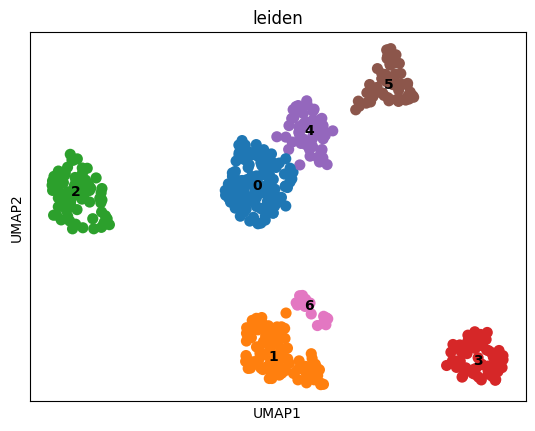

/tmp/ipykernel_1034/600126637.py:8: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}')
/tmp/ipykernel_1034/600126637.py:8: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f'lei

In [ ]:
# Leiden clustering (recommended)
sc.tl.leiden(adata, resolution=0.5)
sc.pl.umap(adata, color='leiden', legend_loc='on data')

# Try multiple resolutions to find optimal granularity
# resolution: Clustering granularity (0.4-1.2, higher = more clusters)
for res in [0.3, 0.5, 0.8, 1.0]:
    sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}')

## Marker Gene Identification:

A marker gene is a specific gene that acts like a molecular name tag or fingerprint for a particular type of cell.
In a complex tissue (like the human liver bud dataset you are working with), there are many different cell types mixed together—such as hepatocytes, endothelial cells, and mesenchymal cells. While all of these cells share the exact same DNA, they "turn on" (express) different genes to do their specific jobs. A marker gene is a gene that is uniquely and highly active in only one specific cell type.
By looking at which marker genes are active, scientists can identify exactly what kind of cell they are looking at in a single-cell RNA-seq dataset.

The function below performs differential expression analysis (DEA) to find genes that are uniquely or highly expressed in each Leiden-defined cell cluster compared to all other clusters. Also, it visualizes Differential Expression Results. These three plotting functions present the differential gene expression results in distinct visual formats.

Group-by-Group Rankings (sc.pl.rank_genes_groups):

sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)
Generates an array of panel plots (one for each cluster) ranking the top 25 differential genes by their test score. Setting sharey=False allows each cluster subplot to have its own y-axis scale, preventing highly expressed genes in one cluster from compressing the visual scale of other clusters.

Expression Heatmap (sc.pl.rank_genes_groups_heatmap):

sc.pl.rank_genes_groups_heatmap(adata, n_genes=10)
Draws a classic clustered heatmap showing the expression of the top 10 marker genes from each cluster. It organizes cells by their cluster assignments along the columns, making co-expressed blocks of cell-type markers clearly visible.

Dotplot Visualization (sc.pl.rank_genes_groups_dotplot):

sc.pl.rank_genes_groups_dotplot(adata, n_genes=5)
Renders a dotplot featuring the top 5 markers for each group. The size of each dot represents the percentage of cells expressing that gene inside the cluster, while the color intensity tracks the average expression level of the gene.


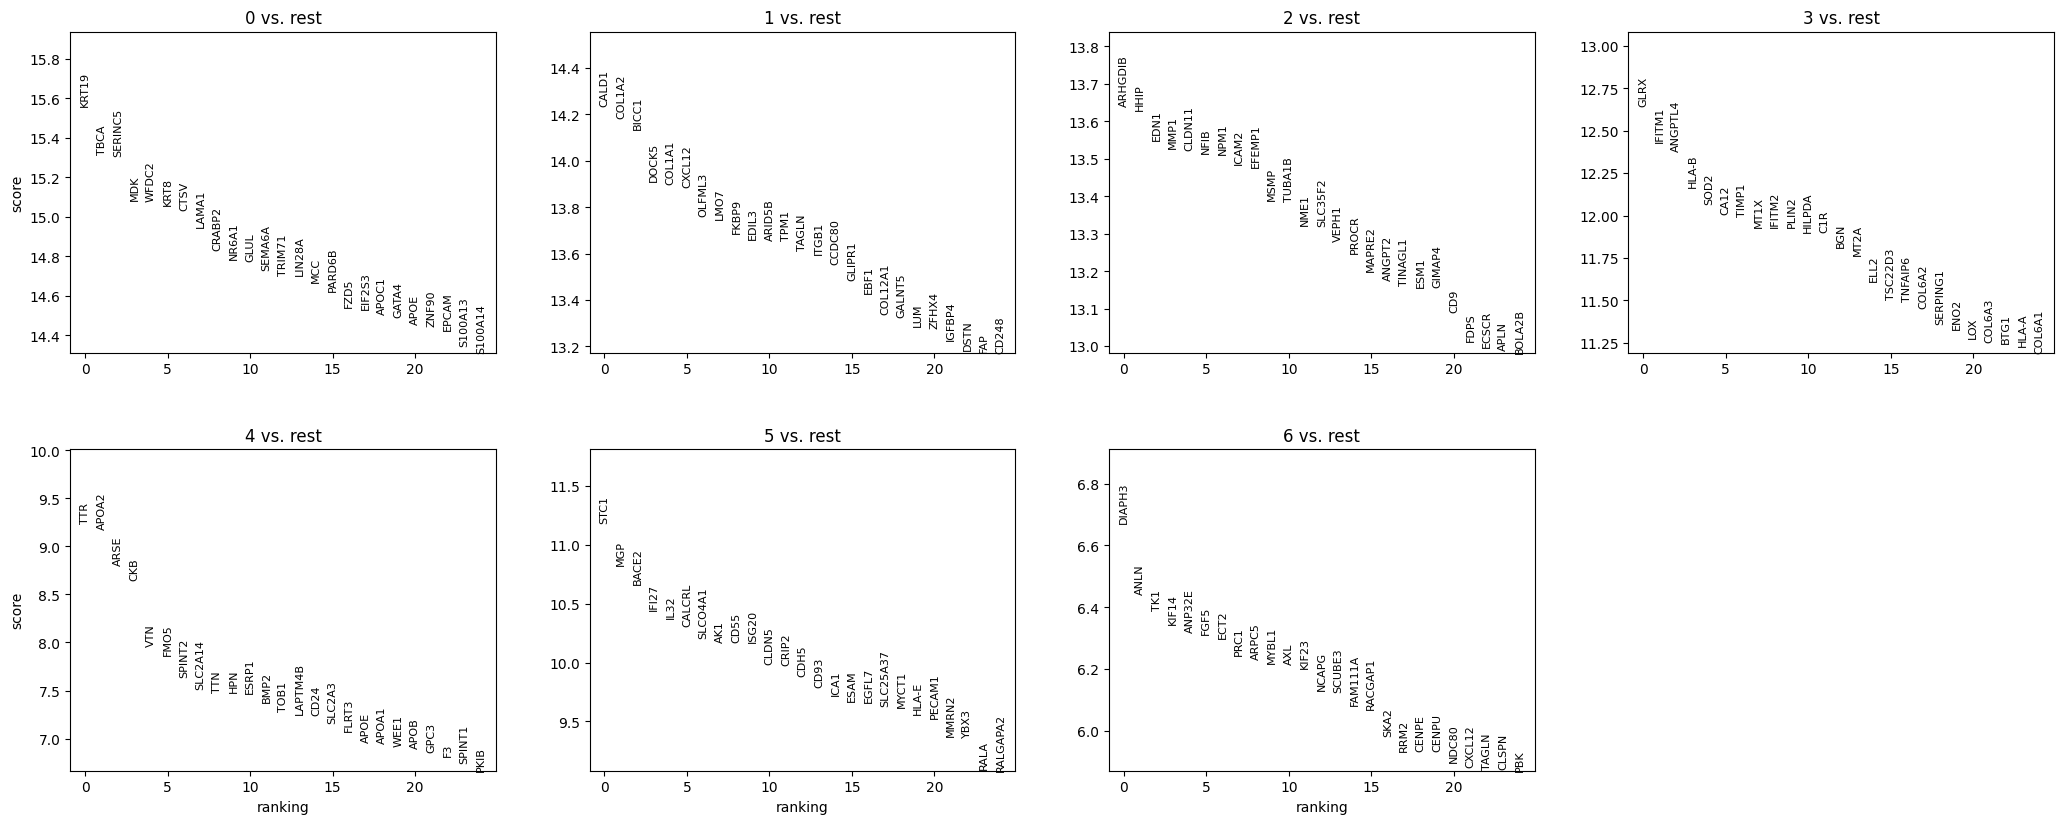

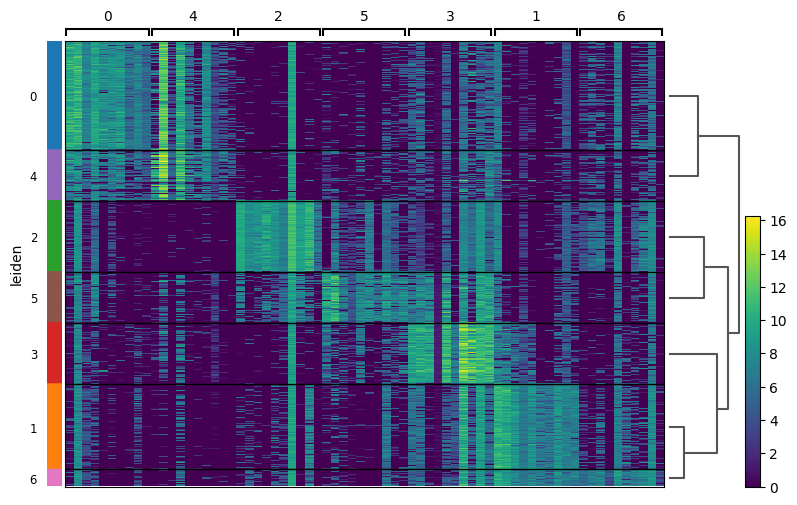

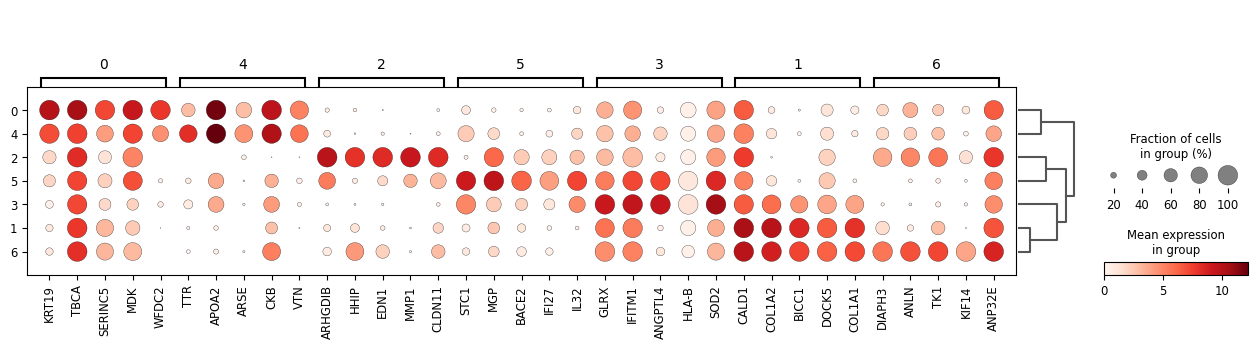

In [ ]:
# Find marker genes for each cluster
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

# Visualize results
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)
sc.pl.rank_genes_groups_heatmap(adata, n_genes=10)
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5)

# Get results as DataFrame
markers = sc.get.rank_genes_groups_df(adata, group='0')

## Key Parameters to Adjust

### Quality Control
- `min_genes`: Minimum genes per cell (typically 200-500)
- `min_cells`: Minimum cells per gene (typically 3-10)
- `pct_counts_mt`: Mitochondrial threshold (typically 5-20%)

### Normalization
- `target_sum`: Target counts per cell (default 1e4)

### Feature Selection
- `n_top_genes`: Number of HVGs (typically 2000-3000)
- `min_mean`, `max_mean`, `min_disp`: HVG selection parameters

### Dimensionality Reduction
- `n_pcs`: Number of principal components (check variance ratio plot)
- `n_neighbors`: Number of neighbors (typically 10-30)

### Clustering
- `resolution`: Clustering granularity (0.4-1.2, higher = more clusters)


Cluster labels should be assigned from marker evidence, not from the cluster number.



Using available marker genes for visualization: ['ARHGDIB', 'TTR', 'AFP', 'KRT19', 'PECAM1', 'COL1A1', 'VIM']


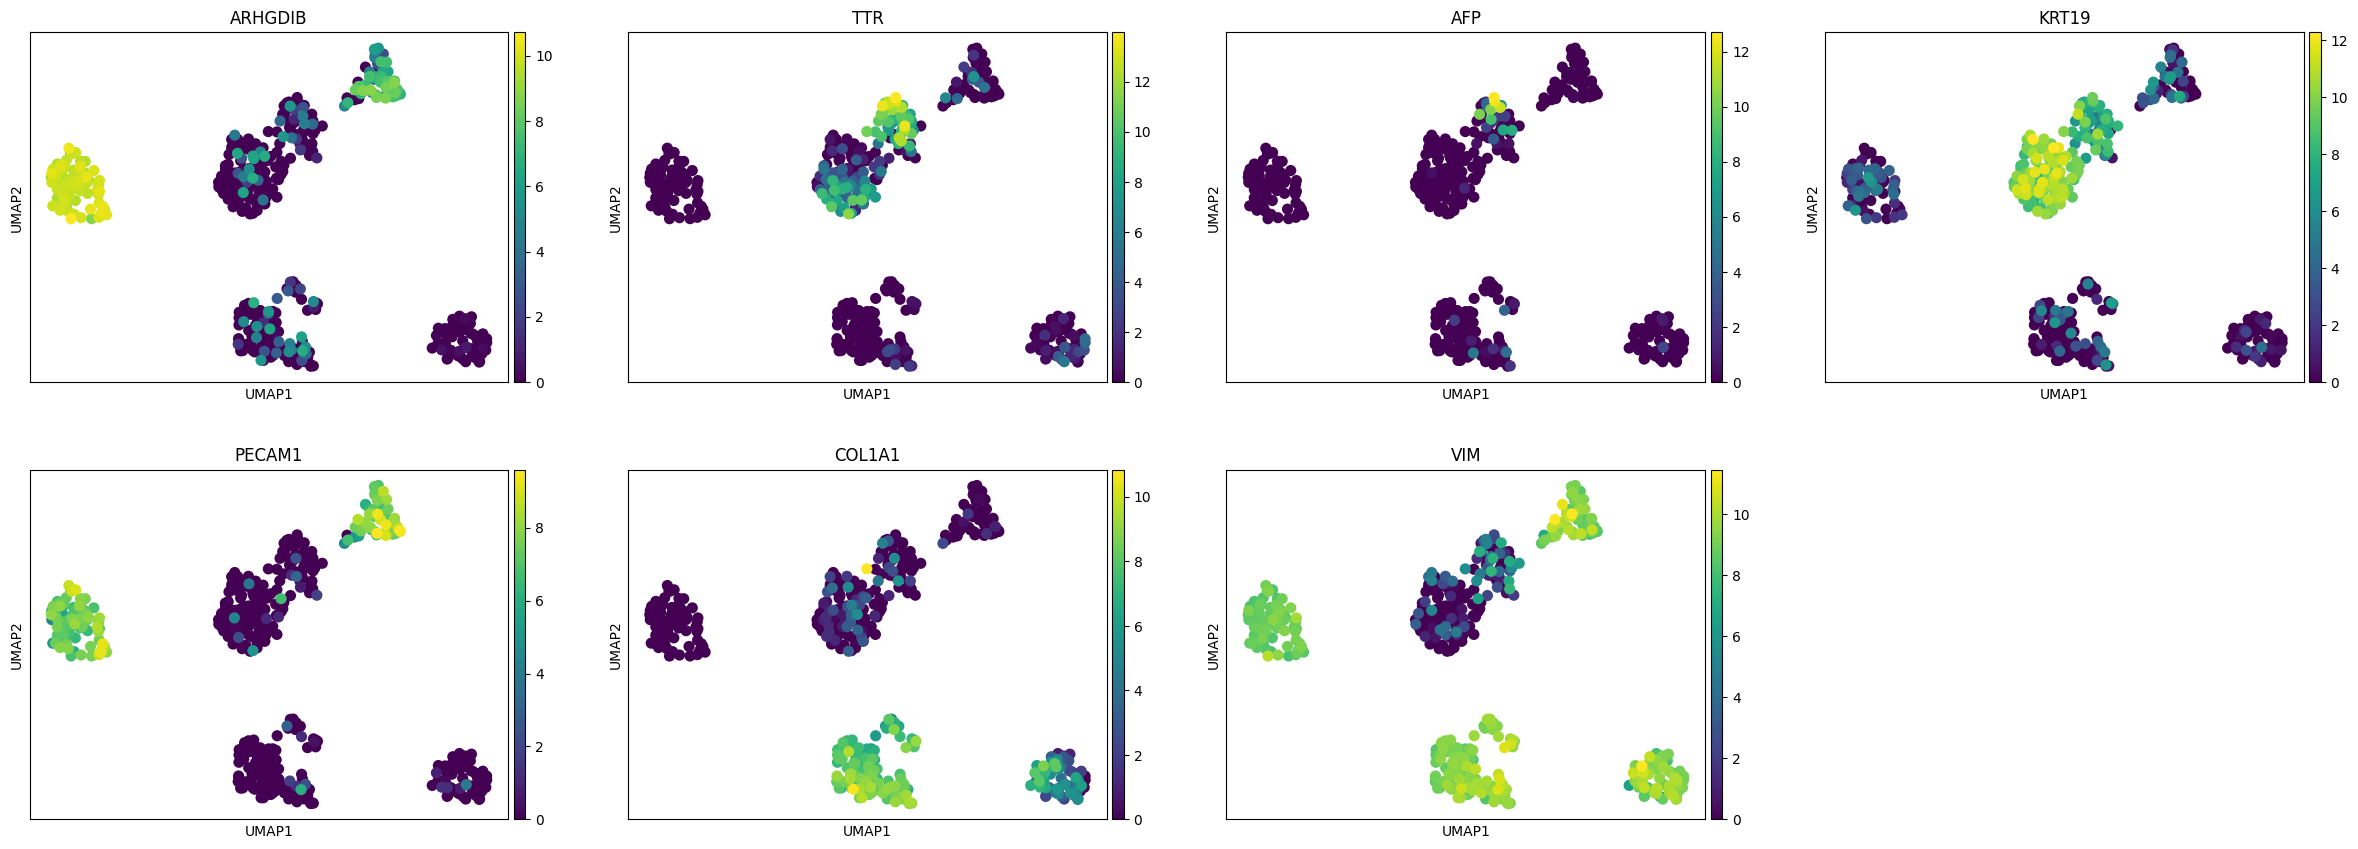

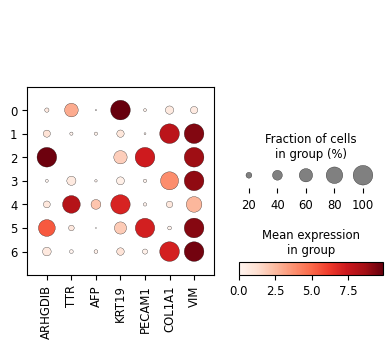

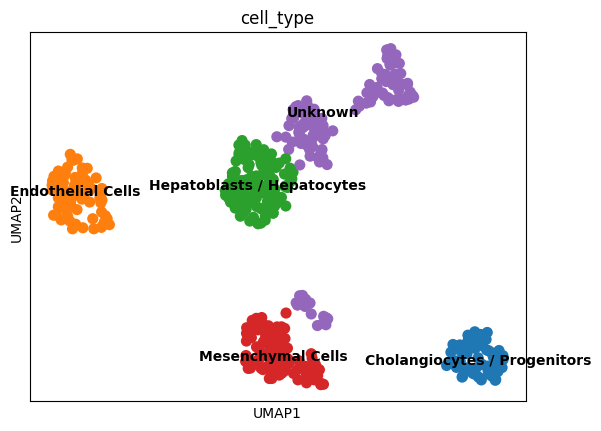

In [ ]:
# Define marker genes relevant to Liver Bud (Hepatocytes, Endothelial, Mesenchymal, etc.)
marker_genes = ['ARHGDIB', 'TTR', 'AFP', 'KRT19', 'PECAM1', 'COL1A1', 'VIM']

# Filter to keep only the marker genes actually present in the dataset
available_markers = [g for g in marker_genes if g in adata.var_names or (adata.raw is not None and g in adata.raw.var_names)]
print(f"Using available marker genes for visualization: {available_markers}")

# Visualize markers
if available_markers:
    sc.pl.umap(adata, color=available_markers, use_raw=True)
    sc.pl.dotplot(adata, var_names=available_markers, groupby='leiden')

# Manual annotation map based on your leiden clustering results
# Adjust these cell types to align with the actual cluster biological markers shown in the dotplot
cluster_to_celltype = {
    '0': 'Hepatoblasts / Hepatocytes',
    '1': 'Mesenchymal Cells',
    '2': 'Endothelial Cells',
    '3': 'Cholangiocytes / Progenitors',
}

# Safely map cluster IDs to cell types
adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_to_celltype).fillna('Unknown')

# Visualize annotated types
sc.pl.umap(adata, color='cell_type', legend_loc='on data')

Examples in the Liver Bud Dataset (GSE81252) analyzing human liver bud organoids, well-known marker genes are:

Cell Type: Marker Gene

  - Hepatocytes (Liver cells):	ALB (Albumin), APOA1	Produces essential liver proteins. AFP (Alpha-fetoprotein) and KRT19 (Keratin 19)

  - Endothelial Cells (Blood vessels):	CD31 (PECAM1), VWF (Von Willebrand factor): Helps form blood vessel walls. FLT1 (VEGFR1 receptor), and CLDN5 (Claudin 5)

  - Mesenchymal Cells (Support tissue):	ACTA2 (alpha-SMA), COL1A1	Provides structural support to the organoid.

  - Pluripotent Stem Cells (Undifferentiated):	POU5F1 (OCT4), NANOG	Keeps cells in an embryonic, stem-like state. COL1A1 / COL2 (Collagens), ACTA2 (Alpha-smooth muscle actin), and DES (Desmin)

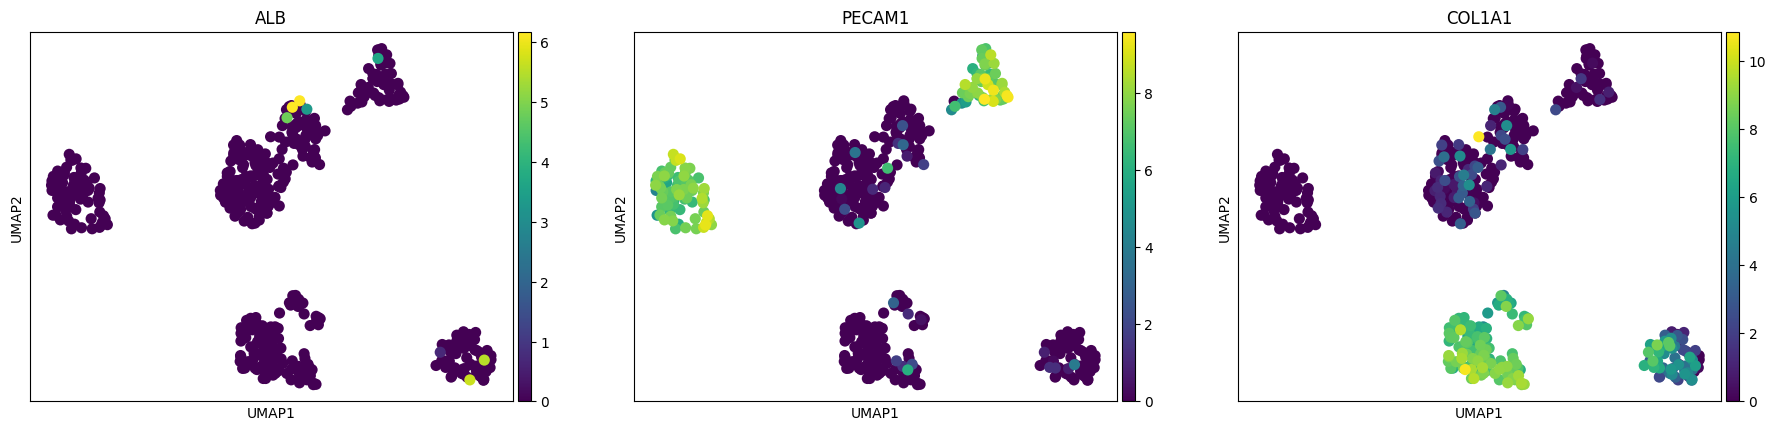

In [ ]:
# Color your UMAP dots by known cell-type markers
sc.pl.umap(adata, color=['ALB', 'PECAM1', 'COL1A1'], cmap='viridis')

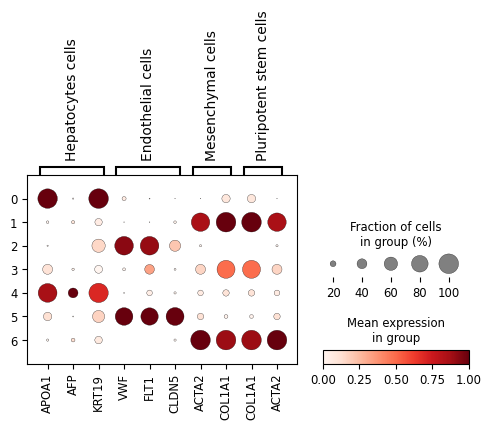

Using available marker genes for visualization: []


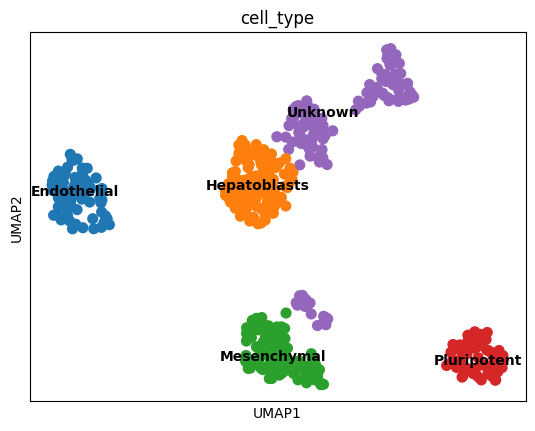

In [ ]:
marker_genes = {
    "Hepatocytes cells": ["ALB", "APOA1", "AFP", "KRT19"],
    "Endothelial cells": ["CD31", "VWF", "FLT1", "CLDN5"],
    "Mesenchymal cells": ["ACTA2", "COL1A1"],
    "Pluripotent stem cells": ["POU5F1", "NANOG", "COL1A1", "ACTA2"],
}

marker_genes_present = {
    cell_type: [gene for gene in genes if gene in adata.var_names]
    for cell_type, genes in marker_genes.items()
}

marker_genes_present = {
    cell_type: genes
    for cell_type, genes in marker_genes_present.items()
    if len(genes) > 0
}

sc.pl.dotplot(
    adata,
    marker_genes_present,
    groupby="leiden",
    standard_scale="var",
    dendrogram=False,
    use_raw=True,
)

# Filter to keep only the marker genes actually present in the dataset
available_markers = [g for g in marker_genes if g in adata.var_names or (adata.raw is not None and g in adata.raw.var_names)]
print(f"Using available marker genes for visualization: {available_markers}")

# Visualize markers
if available_markers:
    sc.pl.umap(adata, color=available_markers, use_raw=True)
    sc.pl.dotplot(adata, var_names=available_markers, groupby='leiden')

# Manual annotation map based on your leiden clustering results
# Adjust these cell types to align with the actual cluster biological markers shown in the dotplot
cluster_to_celltype = {
    '0': 'Hepatoblasts',
    '1': 'Mesenchymal',
    '2': 'Endothelial',
    '3': 'Pluripotent',
}

# Safely map cluster IDs to cell types
adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_to_celltype).fillna('Unknown')

# Visualize annotated types
sc.pl.umap(adata, color='cell_type', legend_loc='on data')

In [ ]:
# Identify available keys in adata.obs to avoid KeyError
obs_keys = adata.obs.columns

# Safely extract values with fallbacks if columns don't exist
cells_before_qc = adata.n_obs
cells_flagged = int(adata.obs["qc_flag"].sum()) if "qc_flag" in obs_keys else 0
high_counts_low_genes = int(adata.obs["qc_high_counts_low_genes"].sum()) if "qc_high_counts_low_genes" in obs_keys else 0
s_phase = int((adata.obs["phase"].astype(str) == "S").sum()) if "phase" in obs_keys else 0
g2m_phase = int((adata.obs["phase"].astype(str) == "G2M").sum()) if "phase" in obs_keys else 0
removed_after_review = int(adata.obs["remove_after_qc_review"].sum()) if "remove_after_qc_review" in obs_keys else 0

# Fallback for adata_qc
if 'adata_qc' in globals():
    cells_after = adata_qc.n_obs
    genes_after = adata_qc.n_vars
else:
    cells_after = adata.n_obs
    genes_after = adata.n_vars

# Build the QC report DataFrame
qc_report = pd.DataFrame({
    "metric": [
        "cells_before_qc",
        "cells_flagged_for_review",
        "cells_high_counts_low_genes",
        "cells_s_phase",
        "cells_g2m_phase",
        "cells_removed_after_review",
        "cells_after_qc",
        "genes_after_qc",
    ],
    "value": [
        cells_before_qc,
        cells_flagged,
        high_counts_low_genes,
        s_phase,
        g2m_phase,
        removed_after_review,
        cells_after,
        genes_after,
    ],
})

qc_report.to_csv("qc_report_summary.csv", index=False)
print("--- QC REPORT SUMMARY ---")
print(qc_report)

# Process primary QC flags if present
if "primary_qc_flag" in obs_keys:
    qc_reason_counts = adata.obs["primary_qc_flag"].value_counts()
    qc_reason_fractions = adata.obs["primary_qc_flag"].value_counts(normalize=True)

    qc_reason_summary = pd.DataFrame({
        "n_cells": qc_reason_counts,
        "fraction": qc_reason_fractions,
    })

    qc_reason_summary.to_csv("qc_flag_reason_summary.csv")
    print("\n--- QC FLAG REASON SUMMARY ---")
    print(qc_reason_summary)
else:
    print("\n'primary_qc_flag' not found in dataset; skipping reason summary.")

--- QC REPORT SUMMARY ---
                        metric  value
0              cells_before_qc    465
1     cells_flagged_for_review      0
2  cells_high_counts_low_genes      0
3                cells_s_phase      0
4              cells_g2m_phase      0
5   cells_removed_after_review      0
6               cells_after_qc    465
7               genes_after_qc   2000

'primary_qc_flag' not found in dataset; skipping reason summary.


# What we did above

We loaded GSE81252 (465 cells × 19,020 genes), ran QC, selected 2,000 HVGs, scales, ran PCA, built a 10-neighbor graph on 40 PCs, applied Leiden clustering and UMAP, found markers, and annotated clusters.

# Main findings
The inputted data are already log2-normalized, and quality controled. So total_counts is a sum of log values, not sequencing depth.

The mitochondrial filter does nothing. pct_counts_mt is 0 for every cell, and the gene list ends at chrY genes (DAZ, CDY1), so no chrM genes appear to be in the matrix. pct_counts_mt < 5 and min_genes=200 remove no cells (465 in, 465 out).

The QC scatter shows a tight, monotone relationship between total and genes detected. There is no high-count/low-gene population. There is only a small low-depth tail of roughly 10 cells (total below about 15k, 2.6–3.5k genes).

# To Do

  * The PCA elbow is gradual. Variance falls steeply through about PC5–8, keeps curving to about PC12–15, and is flat past about PC20. n_pcs=40 sits well into the noise tail; we suggest 15–30 for small homogeneous data.

  * Leiden gives 8 clusters at the default resolution and 7 at 0.5. The leiden_0.3/0.5/0.8/1.0 columns are computed. We should plot and compare the results for different resolutions.

  * The annotation is incomplete and partly unsupported. cluster_to_celltype covers only clusters 0–3, so clusters 4, 5 and 6 become "Unknown". The dotplot suggests 4 is hepatoblast-like (APOA1, AFP, KRT19, TTR), 5 is endothelial (VWF, FLT1, CLDN5, PECAM1), and 6 is mesenchymal (highest ACTA2/COL1A1). Cluster 3 is labeled "Cholangiocytes/Progenitors" in cell 24 and "Pluripotent" in cell 27. Neither is supported, because POU5F1 and NANOG are never shown and the cluster expresses mesenchymal genes. Hard-coded cluster IDs also change whenever resolution or seed changes.

  * We check marker presence against adata.var_names, which holds only the 2,000 HVGs. ALB, POU5F1 and NANOG are silently dropped even though they plot fine from .raw. CD31 is not a gene symbol (PECAM1 is). The second half of that cell loops over the dict keys, so it prints [] and does nothing.

  * The "Pluripotent" marker list reuses COL1A1 and ACTA2, which are the mesenchymal markers, so that group can't discriminate anything.

  * The ground-truth labels are loaded but never used. obs['experiment'] and obs['assignment_LB'] are in adata.obs and could validate the clusters.
